# Introduction to PVT Single Point Positioning

This notebook explores the fundamental concepts of Position, Velocity, and Time (PVT) determination using pseudoranges, a core technique in Global Navigation Satellite Systems (GNSS) like GPS. We will specifically focus on single-point positioning in a 2D scenario, where a receiver estimates its location and clock bias relative to a set of known transmitters.

### Exercise Overview:

This exercise guides you through understanding:

1.  **Pseudorange Visualization**: How to represent pseudoranges as circles and why they don't perfectly intersect.
2.  **Impact of Receiver Clock Bias**: The crucial role of receiver clock errors and their effect on pseudorange measurements.
3.  **Handling Negative Pseudoranges**: What negative pseudoranges signify and why they cannot be plotted directly.
4.  **Least Squares Method**: Setting up and solving a linearized system of equations to estimate receiver position and clock offset.
5.  **Interpreting Results**: Analyzing position corrections and clock offsets for different scenarios.



### Setup

First, let's set up our environment by importing the necessary libraries and defining the core parameters for our PVT calculations. This includes the positions of our transmitters and the pseudorange measurements for both Case A and Case B.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

In [ ]:
# Position of the transmitters (T)
T = np.array([
    [5, 2],
    [-2, 4],
    [0, -4]
])

# Pseudoranges for Case A (rho_A)
rho_A = np.array([
    4.32,
    4.54,
    5.40,
])

# Apriori receiver position (x_0)
x_0 = np.array([1, 1])

# Pseudoranges for Case B (rho_B)
rho_B = np.array([
    -0.38,
    -0.26,
    0.90
])

In [ ]:
# Helper function to compute pre-fit residuals
def compute_prefits_vectorized(rho_observed, T, x_0):
    # Calculates the difference between observed pseudoranges and
    # the geometric range from transmitters to the a-priori receiver position.
    return rho_observed - np.linalg.norm(T - x_0, axis=1)

In [ ]:
# Helper function to compute the design matrix (H)
def compute_design_matrix(T, x_0):
    # Calculate a-priori geometric ranges from transmitters to x_0
    r_apriori = np.linalg.norm(T - x_0, axis=1)

    # Geometric components of the design matrix (partial derivatives wrt x, y)
    H_geometry = (T - x_0) / r_apriori[:, np.newaxis]

    # Clock bias component of the design matrix (a column of ones)
    H_clock = np.ones((len(T), 1))

    # Combine geometric and clock components to form the full design matrix H
    H = np.column_stack((H_geometry, H_clock))
    return H

---

### Exercise 1: Draw the transmitters and the circles corresponding to the different pseudoranges (Case A).

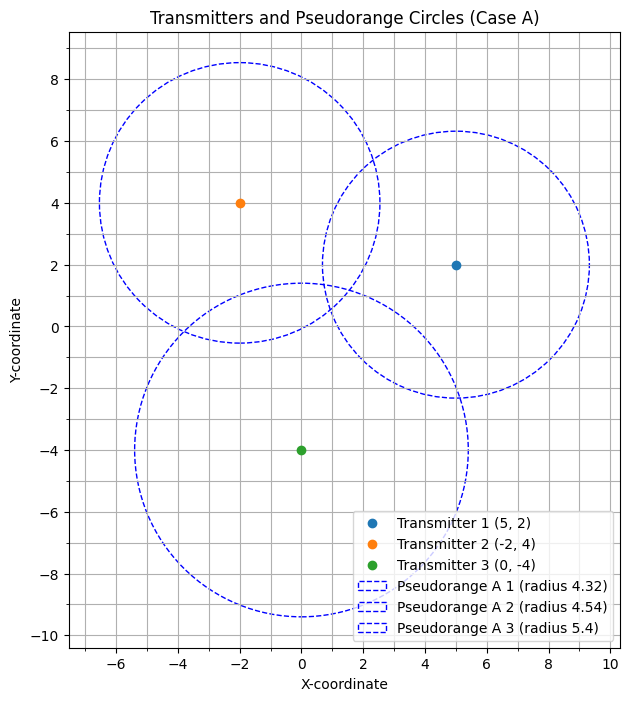

In [ ]:
plt.figure(figsize=(8, 8))

# Plot transmitters
for i, t_coord in enumerate(T):
    plt.plot(t_coord[0], t_coord[1], 'o', label=f'Transmitter {i+1} ({t_coord[0]}, {t_coord[1]})')

# Plot circles for pseudoranges (Case A)
for i, (t_coord, r) in enumerate(zip(T, rho_A)):
    circle = plt.Circle((t_coord[0], t_coord[1]), r, color='blue', fill=False, linestyle='--', label=f'Pseudorange A {i+1} (radius {r})')
    plt.gca().add_patch(circle)

# Set plot limits and labels
min_x = min([t[0] - r for t, r in zip(T, rho_A)]) - 1
max_x = max([t[0] + r for t, r in zip(T, rho_A)]) + 1
min_y = min([t[1] - r for t, r in zip(T, rho_A)]) - 1
max_y = max([t[1] + r for t, r in zip(T, rho_A)]) + 1

plt.xlim(min_x, max_x)
plt.ylim(min_y, max_y)
plt.xlabel('X-coordinate')
plt.ylabel('Y-coordinate')
plt.title('Transmitters and Pseudorange Circles (Case A)')
plt.gca().set_aspect('equal', adjustable='box') # Ensure circles appear round

# Set major and minor ticks
plt.gca().xaxis.set_major_locator(MultipleLocator(2))
plt.gca().xaxis.set_minor_locator(MultipleLocator(1))
plt.gca().yaxis.set_major_locator(MultipleLocator(2))
plt.gca().yaxis.set_minor_locator(MultipleLocator(1))

plt.grid(True, which='both') # Ensure grid is shown for both major and minor ticks
plt.legend()
plt.show()

### Answer to Exercise 1:

The plot above visualizes the three transmitters and their corresponding pseudorange circles for Case A. Each circle's center is a transmitter, and its radius is the measured pseudorange to that transmitter. Observe how these circles are displayed on the 2D plane.

---

### Exercise 2: Do all the circles intersect at a single point? Why?

### Answer to Exercise 2:

As seen in the plot above, the circles corresponding to the pseudoranges do **not** intersect at a single point. This is a fundamental concept in positioning:

*   **True Range vs. Pseudorange**: If we were using *true geometric ranges* from the receiver to each transmitter, the circles would ideally intersect at a single point, which would be the receiver's precise location.

*   **Receiver Clock Bias**: In reality, GNSS receivers measure *pseudoranges*. These are the geometric range plus an unknown offset caused by the difference between the receiver's internal clock and the highly accurate atomic clocks on the transmitters. Since each pseudorange is biased by this unknown receiver clock error, the circles typically won't intersect precisely at a single point.

Least squares methods are used to estimate both the receiver's position (X, Y) and this unknown clock bias simultaneously, finding the best-fit solution that minimizes the errors among the non-intersecting pseudoranges.

---

### Exercise 3: Another receiver, located at the same position as the first receiver, measures the pseudoranges below. Is it possible to draw all the pseudorange circles for this receiver?

$$\rho_1' = -0.38\ \text{m} \\ \rho_2' = -0.26\ \text{m} \\ \rho_3' = 0.90\ \text{m}$$

Pseudorange B 1 has a negative value (-0.38 m) and cannot be drawn as a real circle.
Pseudorange B 2 has a negative value (-0.26 m) and cannot be drawn as a real circle.


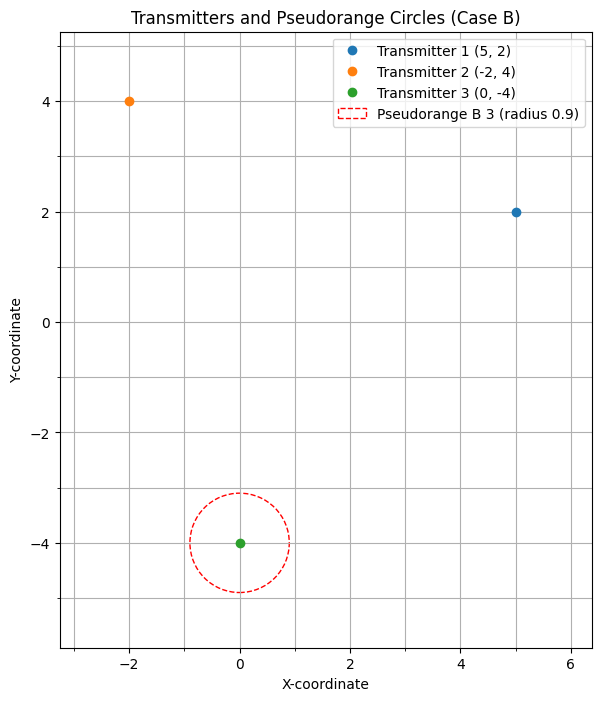

In [ ]:
plt.figure(figsize=(8, 8))

# Plot transmitters
for i, t_coord in enumerate(T):
    plt.plot(t_coord[0], t_coord[1], 'o', label=f'Transmitter {i+1} ({t_coord[0]}, {t_coord[1]})')

# Plot circles for pseudoranges B
for i, (t_coord, r) in enumerate(zip(T, rho_B)):
    if r > 0: # Only plot circles for positive pseudoranges
        circle = plt.Circle((t_coord[0], t_coord[1]), r, color='red', fill=False, linestyle='--', label=f'Pseudorange B {i+1} (radius {r})')
        plt.gca().add_patch(circle)
    else:
        print(f"Pseudorange B {i+1} has a negative value ({r:.2f} m) and cannot be drawn as a real circle.")

# Set plot limits and labels (using rho_A limits for consistency, or dynamically adjust)
min_x = min([t[0] - abs(r) for t, r in zip(T, rho_B)]) - 1 # Use absolute value for negative ranges for boundary estimation
max_x = max([t[0] + abs(r) for t, r in zip(T, rho_B)]) + 1
min_y = min([t[1] - abs(r) for t, r in zip(T, rho_B)]) - 1
max_y = max([t[1] + abs(r) for t, r in zip(T, rho_B)]) + 1

plt.xlim(min_x, max_x)
plt.ylim(min_y, max_y)
plt.xlabel('X-coordinate')
plt.ylabel('Y-coordinate')
plt.title('Transmitters and Pseudorange Circles (Case B)')
plt.gca().set_aspect('equal', adjustable='box') # Ensure circles appear round

# Set major and minor ticks
plt.gca().xaxis.set_major_locator(MultipleLocator(2))
plt.gca().xaxis.set_minor_locator(MultipleLocator(1))
plt.gca().yaxis.set_major_locator(MultipleLocator(2))
plt.gca().yaxis.set_minor_locator(MultipleLocator(1))

plt.grid(True, which='both') # Ensure grid is shown for both major and minor ticks
plt.legend()
plt.show()

### Answer to Exercise 3:

No, it is **not possible to draw all the pseudorange circles** for this receiver. As indicated by the output of the plotting code, two of the three pseudoranges ($\rho_1'$ and $\rho_2'$) are negative.

A circle is defined by a center and a positive radius. A negative radius is physically meaningless in this context, as distance cannot be negative. Therefore, we can only plot the circle corresponding to $\rho_3' = 0.90\ \text{m}$. The plot above shows only one circle for Case B.

---

### Exercise 4: What does it mean for the pseudoranges to be negative?

### Answer to Exercise 4:

A negative pseudorange, like $-0.38\ \text{m}$ or $-0.26\ \text{m}$, is a result of the same receiver clock bias that causes the pseudorange circles not to intersect perfectly. Mathematically, a pseudorange ($\rho$) is defined as:

$$\rho = R + c \cdot \delta t_{rcvr}$$

where:
*   $R$ is the true geometric range (always positive).
*   $c$ is the speed of light.
*   $\delta t_{rcvr}$ is the receiver clock offset (which can be positive or negative).

If the receiver's clock is significantly *ahead* of the GPS time, meaning $\delta t_{rcvr}$ is a large negative value, it can cause the calculated pseudorange $\rho$ to become negative, even though the true geometric range $R$ is positive. This implies that the receiver is reporting the signal arriving *before* it was supposedly transmitted, which is an artifact of the clock offset. In practice, this highlights a large clock error that needs to be estimated and corrected by the positioning algorithm.

---

### Exercise 5: Set up the system of equations (Least Squares) that you would use to compute the position solution for cases above around the initial *a-priori* point $(1, 1)$.

The positioning problem can be linearized around an *a-priori* estimated receiver position $(x_0, y_0)$ and an *a-priori* clock offset $(b_0)$, forming a system of linear equations that can be solved using Least Squares. The goal is to find the correction vector $\Delta \mathbf{x} = [\Delta x, \Delta y, \Delta b]^T$ that, when added to the *a-priori* state, provides the improved position and clock offset.

The linearized observation equation for each transmitter $i$ is:

$$ \delta \rho_i \approx \frac{\partial R_i}{\partial x} \Delta x + \frac{\partial R_i}{\partial y} \Delta y + \frac{\partial (c \cdot \delta t_{rcvr})}{\partial \delta t_{rcvr}} \Delta b $$

This can be written in matrix form as:

$$ \mathbf{H} \Delta \mathbf{x} = \mathbf{\delta \rho} $$

where:
*   $\mathbf{\delta \rho}$ is the vector of 'pre-fit residuals' or differences between observed pseudoranges and predicted pseudoranges (based on the *a-priori* position).
*   $\mathbf{H}$ is the design matrix, containing the partial derivatives of the pseudoranges with respect to the receiver's position and clock offset.

Specifically, for $N$ transmitters and a 2D position $(x,y)$ plus clock bias $b$, the design matrix $\mathbf{H}$ and the pre-fit residual vector $\mathbf{\delta \rho}$ are constructed as follows:

*   **Receiver A-Priori State**: $\mathbf{x}_{apriori} = [x_0, y_0, b_0]^T$. In this problem, our initial estimate of the receiver's clock offset ($b_0$) is zero, and the initial position is $(1,1)$, so $\mathbf{x}_{apriori} = [1, 1, 0]^T$.

*   **Pre-fit Residuals ($\mathbf{\delta \rho}$)**: For each transmitter $i$, the pre-fit residual is calculated as:

    $$ \delta \rho_i = \rho_{i,observed} - R_{i,apriori} $$

    where $R_{i,apriori}$ is the geometric distance between the $i$-th transmitter and the *a-priori* receiver position $(x_0, y_0)$.

*   **Design Matrix ($\mathbf{H}$)**: For each transmitter $i$ located at $(T_{ix}, T_{iy})$ and *a-priori* receiver position $(x_0, y_0)$:

    $$ \mathbf{H}_i = \left[ \frac{T_{ix} - x_0}{R_{i,apriori}}, \frac{T_{iy} - y_0}{R_{i,apriori}}, 1 \right] $$

    The $1$ in the third column accounts for the receiver clock bias. The full $\mathbf{H}$ matrix is formed by stacking these rows for all transmitters.

*   **Least Squares Solution**: The correction vector $\Delta \mathbf{x}$ is then found by:

    $$ \Delta \mathbf{x} = (\mathbf{H}^T \mathbf{H})^{-1} \mathbf{H}^T \mathbf{\delta \rho} $$

    The improved receiver state is
    
    $$ \mathbf{x} = \mathbf{x}_{apriori} + \Delta \mathbf{x} $$.

The `compute_prefits_vectorized` and `compute_design_matrix` functions defined in the 'Setup' section implement these steps to form the necessary components for the Least Squares solution.

### Code for Exercise 5 (Calculations):

In [ ]:
# Calculate pre-fit residuals for Case A
prefits_A = compute_prefits_vectorized(rho_A, T, x_0)
print(f"Pre-fit residuals for Case A (delta_rho_A): {prefits_A}")

# Compute the design matrix H (common for both cases)
H = compute_design_matrix(T, x_0)
print(f"\nDesign Matrix (H):\n{H}")

# Compute the inverse of (H^T * H) * H^T
H_inv = np.dot(np.linalg.inv(np.dot(H.T, H)), H.T)

# Calculate the correction vector Delta_x for Case A
Delta_x_A =  np.dot(H_inv, prefits_A)
print(f"\nCorrection vector for Case A (Delta_x_A): {Delta_x_A}")

# Calculate the updated receiver position for Case A
x_A = x_0 + Delta_x_A[:2]
print(f"Updated receiver position for Case A (x_A): {x_A}")

# Calculate pre-fit residuals for Case B
prefits_B = compute_prefits_vectorized(rho_B, T, x_0)
print(f"\nPre-fit residuals for Case B (delta_rho_B): {prefits_B}")

# Calculate the correction vector Delta_x for Case B
Delta_x_B =  np.dot(H_inv, prefits_B)
print(f"Correction vector for Case B (Delta_x_B): {Delta_x_B}")

# Calculate the updated receiver position for Case B
x_B = x_0 + Delta_x_B[:2]
print(f"Updated receiver position for Case B (x_B): {x_B}")

Pre-fit residuals for Case A (delta_rho_A): [0.19689437 0.29735931 0.30098049]

Design Matrix (H):
[[ 0.9701425   0.24253563  1.        ]
 [-0.70710678  0.70710678  1.        ]
 [-0.19611614 -0.98058068  1.        ]]

Correction vector for Case A (Delta_x_A): [-0.06603052 -0.02213808  0.26632267]
Updated receiver position for Case A (x_A): [0.93396948 0.97786192]

Pre-fit residuals for Case B (delta_rho_B): [-4.50310563 -4.50264069 -4.19901951]
Correction vector for Case B (Delta_x_B): [-0.05469454 -0.19646385 -4.40239465]
Updated receiver position for Case B (x_B): [0.94530546 0.80353615]


### Answer to Exercise 5:

The code above calculates the pre-fit residuals, the design matrix, and then uses the Least Squares formula to determine the correction vectors ($\Delta \mathbf{x}$) for both Case A and Case B. These correction vectors include corrections for both the position ($\Delta x, \Delta y$) and the receiver clock bias ($\Delta b$). The updated receiver positions for both cases are also computed by adding the position components of the correction vectors to the *a-priori* position.

For this problem, the numerical least-squares solutions are:

- Case A: $\Delta \mathbf{x}_A \approx [-0.066,\,-0.022,\,0.266]^T$ and the improved estimate is approximately $(0.934,\,0.978)$ with a clock bias of about $0.266\,\text{m}$, equivalent to about $0.89\,\text{ns}$ in time.
- Case B: $\Delta \mathbf{x}_B \approx [-0.055,\,-0.196,\,-4.402]^T$ and the improved estimate is approximately $(0.945,\,0.804)$ with a clock bias of about $-4.402\,\text{m}$, equivalent to about $-14.7\,\text{ns}$ in time.

These values show that the receiver clock bias is the dominant error in the pseudorange observations and is what prevents the circles from intersecting at a single point.

In [ ]:
# Numerical least-squares solution for the two cases
prefits_A = compute_prefits_vectorized(rho_A, T, x_0)
prefits_B = compute_prefits_vectorized(rho_B, T, x_0)
H = compute_design_matrix(T, x_0)
H_inv = np.linalg.inv(H.T @ H) @ H.T

Delta_x_A = H_inv @ prefits_A
Delta_x_B = H_inv @ prefits_B

x_A = x_0 + Delta_x_A[:2]
x_B = x_0 + Delta_x_B[:2]

print('Case A pre-fit residuals:', prefits_A)
print('Case A correction vector:', Delta_x_A)
print('Case A estimated position:', x_A)
print('Case A clock bias estimate:', Delta_x_A[2])

print('\nCase B pre-fit residuals:', prefits_B)
print('Case B correction vector:', Delta_x_B)
print('Case B estimated position:', x_B)
print('Case B clock bias estimate:', Delta_x_B[2])

### Exercise 6: If the position solutions are $(1, 2, 1\times 10^{-9})$ and $(1, 2, -15\times 10^{-9})$ for the two cases, what is the difference between them?

### Answer to Exercise 6:

The difference is found by subtracting the two state vectors component by component:

$$
\begin{bmatrix}
1 \\ 2 \\ 1\times10^{-9}
\end{bmatrix}
-
\begin{bmatrix}
1 \\ 2 \\ -15\times10^{-9}
\end{bmatrix}
=
\begin{bmatrix}
0 \\ 0 \\ 16\times10^{-9}
\end{bmatrix}
$$

So the two receiver solutions are located at the same position $(1,2)$, but their clock offsets differ by

$$
16\times10^{-9}\ \text{s}
$$

which is about $c \cdot 16\times10^{-9} \approx 4.8\,\text{m}$ in equivalent distance.

### Exercise 7: What is the clock offset of the receivers?

### Answer to Exercise 7:

The clock offset is the third component of the estimated state vector. Therefore:

- Receiver A: $b_A = 1\times10^{-9}\,\text{s}$
- Receiver B: $b_B = -15\times10^{-9}\,\text{s}$

These values represent the receiver clock bias relative to the reference time used by the transmitters. One receiver clock is slightly ahead of the system time, while the other is significantly behind it. This clock bias is exactly what creates the pseudorange offset and prevents the circles from intersecting at a single point.

---